In [ ]:
%matplotlib inline
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec
import matplotlib.colors as colors
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib import cm
from matplotlib.patches import Patch
import seaborn as sns

import scanpy as sc
import snapatac2 as snap

snap.__version__



plt.rcParams['figure.dpi'] = 167
plt.rcParams['font.size'] = 14
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [font for font in 'Liberation Sans, DejaVu Sans, Arial, Helvetica, Lucida Grande, Verdana, Geneva, Lucid, Avant Garde, sans-serif'.split(', ')] 
plt.rcParams['mathtext.fontset'] = 'stixsans'

plt.rcParams['axes.linewidth'] = 1
plt.rcParams['grid.linewidth'] = 1
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 6




/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [85]:

scanpy_colors = [    
    '#1f77b4',
    '#ff7f0e', 
    '#2ca02c',
    '#d62728', 
    '#9467bd', 
    '#8c564b', 
    '#e377c2', 
    '#bcbd22', 
    '#17becf', 
    '#c7c7c7', 
    '#ffbb78',
    '#98df8a']
scanpy_cluster = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']
scanpy_color_map = dict(zip(scanpy_cluster, scanpy_colors))

## Load Data

In [8]:
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')

# Load ATAC gene activity data
data_filter = sc.read_h5ad(os.path.join(Union_cell_subdir, '_SNAPataC_analysis', 'binnedGenome_unioncells_filtered.h5ad'))
data = sc.read_h5ad(os.path.join(Union_cell_subdir, '_SNAPataC_analysis', 'binnedGenome_all_unioncells.h5ad'))

data.obs['filtered_leiden'] = data.obs.index.map(data_filter.obs['filtered_leiden']).fillna('debrisOdoublets')


data.obs['debris_doublets_flag'] = data.obs.apply(lambda row: 
    'debrisNdoublet' if row['DNA_debris'] == 'YES' and row['amulet_doublet_atac'] == True \
        else ('doublets' if row['amulet_doublet_atac'] == True \
            else ('Debris' if row['DNA_debris'] == 'YES' else 'clean')), axis=1)


# Load RNA gene expression data 
h5_rna_union_file = os.path.join(Union_cell_subdir, 'Union_3set_rna_with_RNA_cluster.h5ad')
h5_rna_union = sc.read_h5ad(h5_rna_union_file)

/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/anndata/_core/anndata.py:1808: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [9]:
data_filter, h5_rna_union

(AnnData object with n_obs × n_vars = 2286 × 6062095
     obs: 'n_fragment', 'frac_dup', 'frac_mito', 'rna_pass_CR', 'atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS', '_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', '_3set_identified_by_atac', 'DNA_debris', 'amulet_doublet_atac', 'leiden_RNA_scVI', 'total_fragments', 'FRIP_raw_peaks', 'FRIP_entropy_peaks', 'FRIP_tss_peaks', 'FRIP_frip_peaks', 'nucleosome_signal', 'tsse', 'leiden', 'leiden_scanpy', 'filtered_leiden'
     var: 'count', 'selected'
     uns: 'DNA_debris_colors', 'TSS_profile', '_3set_identified_by_atac_colors', 'amulet_doublet_atac_colors', 'filtered_distance', 'filtered_leiden_colors', 'filtered_spectral_eigenvalue', 'frac_overlap_TSS', 'leiden_RNA_scVI_colors', 'leiden_colors', 'leiden_scanpy', 'leiden_scanpy_colors', 'library_tsse', 'reference_sequences', 'spectral_eigenvalue'
     obsm: 'X_spectral', 'X_umap', 'filtered_X_spectral', 'filtered_X_umap', 'fragment_paired'
     obsp: 'distances', 'fi

# Correlation on feature expression at cluster level 

In [39]:
h5_rna_union.var_names_make_unique()

In [40]:

RNAcluster_GEX = pd.DataFrame(index =h5_rna_union.var_names)
for rna_c in h5_rna_union.obs['leiden_RNA_scVI'].unique():
    RNAcluster_GEX[f'rna_c{rna_c}'] = h5_rna_union[h5_rna_union.obs['leiden_RNA_scVI'] == rna_c].X.mean(axis=0).A1

In [48]:
RNAcluster_GEX_commonFeature[:4]

,rna_c1,rna_c3,rna_c5,rna_c6,rna_c2,rna_c0,rna_c8,rna_c4,rna_c7,rna_c10,rna_c11,rna_c9
LINC01409,0.085399,0.071942,0.138393,0.095694,0.138408,0.185039,0.253968,0.0,0.128713,0.0,0.0,0.0
LINC01128,0.066116,0.039568,0.084821,0.028708,0.038062,0.051181,0.063492,0.0,0.059406,0.0,0.0,0.0
LINC00115,0.019284,0.007194,0.008929,0.009569,0.027682,0.033465,0.111111,0.0,0.039604,0.0,0.0,0.0
FAM41C,0.002755,0.000000,0.000000,0.000000,0.003460,0.007874,0.047619,0.0,0.009901,0.0,0.0,0.0


In [24]:
gene_matrix = snap.pp.make_gene_matrix(data, snap.genome.hg38)
gene_matrix

AnnData object with n_obs × n_vars = 2384 × 60606
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'rna_pass_CR', 'atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS', '_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', '_3set_identified_by_atac', 'DNA_debris', 'amulet_doublet_atac', 'leiden_RNA_scVI', 'total_fragments', 'FRIP_raw_peaks', 'FRIP_entropy_peaks', 'FRIP_tss_peaks', 'FRIP_frip_peaks', 'nucleosome_signal', 'tsse', 'leiden', 'leiden_scanpy', 'filtered_leiden', 'debris_doublets_flag'

In [31]:
ATACcluster_GeneActivity = pd.DataFrame(index = gene_matrix.var_names)
for atac_c in data.obs['filtered_leiden'].unique():
    ATACcluster_GeneActivity[f'atac_c{atac_c}'] = gene_matrix[gene_matrix.obs['filtered_leiden'] == atac_c].X.mean(axis=0).A1

In [49]:
ATACcluster_GeneActivity_commonFeature[:4 ]

,atac_c9,atac_c0,atac_c2,atac_c3,atac_c5,atac_cdebrisOdoublets,atac_c4,atac_c11,atac_c1,atac_c8,atac_c6,atac_c7,atac_c10
LINC01409,0.216216,0.013699,0.408889,0.190244,1.089474,3.061224,0.664975,0.602941,0.741667,0.445860,0.146067,1.061798,1.028571
LINC00115,0.087838,0.003425,0.111111,0.039024,0.357895,0.785714,0.279188,0.176471,0.225000,0.108280,0.039326,0.286517,0.450000
LINC01128,0.087838,0.017123,0.128889,0.043902,0.373684,2.459184,0.294416,0.286765,0.241667,0.159236,0.056180,0.449438,0.507143
FAM41C,0.013514,0.006849,0.173333,0.053659,0.147368,1.377551,0.121827,0.176471,0.145833,0.076433,0.044944,0.247191,0.150000


In [116]:
# Use common features to compute correlation
#ATACcluster_GeneActivity.index.isin(RNAcluster_GEX.index).sum(), RNAcluster_GEX.index.isin(ATACcluster_GeneActivity.index).sum()
common_futures = ATACcluster_GeneActivity.index.intersection(RNAcluster_GEX.index)
ATACcluster_GeneActivity_commonFeature = ATACcluster_GeneActivity.loc[common_futures]
RNAcluster_GEX_commonFeature = RNAcluster_GEX.loc[common_futures]
print(ATACcluster_GeneActivity_commonFeature.shape, RNAcluster_GEX_commonFeature.shape)

corr_df = pd.DataFrame(index=ATACcluster_GeneActivity_commonFeature.columns, columns=RNAcluster_GEX_commonFeature.columns)
for rna_c in RNAcluster_GEX_commonFeature.columns:
    pass
    corr_df[rna_c] = ATACcluster_GeneActivity_commonFeature.corrwith(RNAcluster_GEX_commonFeature[rna_c], axis=0)

(16631, 13) (16631, 12)


In [ ]:

filtered_leiden_colors_map = dict(zip( scanpy_cluster + ['debrisOdoublets'], scanpy_colors + ['black'],))


/tmp/ipykernel_2208856/1589504633.py:23: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_data = correlation_mat.applymap(lambda x: f"{x:.2f}" if np.round(x,2) != 0 else "")


Text(0.8, -0.2, 'ATAC\ncluster')

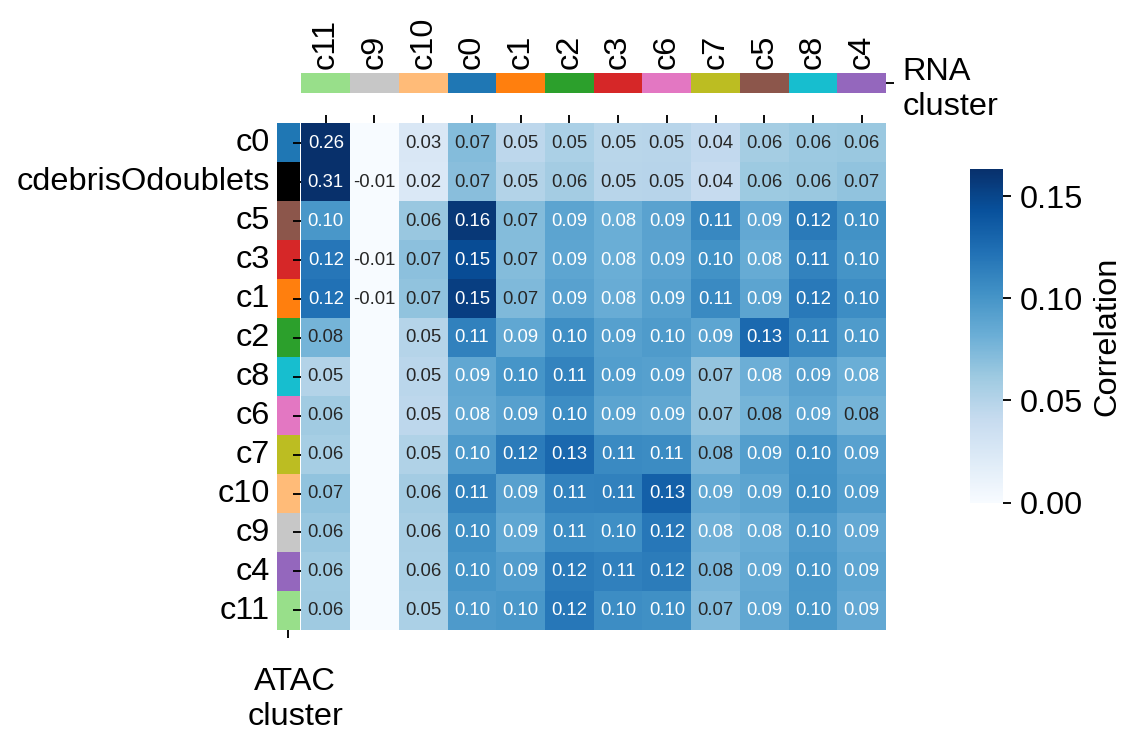

In [124]:
correlation_mat = corr_df.copy()
correlation_mat.index = correlation_mat.index.str.replace('atac_c', 'c')
correlation_mat.columns = correlation_mat.columns.str.replace('rna_c', 'c')
correlation_mat_index = correlation_mat.index.astype(str)
correlation_mat_columns = correlation_mat.columns.astype(str)


col_colors = pd.DataFrame({
    'RNA\ncluster': correlation_mat.columns.str.replace('c', '').map(filtered_leiden_colors_map),
}, index= correlation_mat.columns.values)
row_colors = pd.DataFrame({
    '': correlation_mat.index.str.replace('c', '').map(filtered_leiden_colors_map),
    # 'ATAC\ncluster': correlation_mat.index.str.replace('atac_c', '').map(filtered_leiden_colors_map),
}, index=correlation_mat.index.values)


c_sd = correlation_mat.values.std()
c_mean = correlation_mat.values.mean()
c_min = np.max((c_mean - 2*c_sd, 0))
c_max = c_mean + 2*c_sd
c_center = 0.5 * (c_min + c_max)

annot_data = correlation_mat.applymap(lambda x: f"{x:.2f}" if np.round(x,2) != 0 else "")

g = sns.clustermap(correlation_mat, col_colors=col_colors, row_colors=row_colors, 
                   annot = annot_data, fmt='', xticklabels=True, yticklabels=True,
                #    annot= False,   xticklabels=True, yticklabels=True,
                   col_cluster=True, row_cluster=True, 
                   cmap='Blues', 
                   cbar_pos=(0.8, 0.25, 0.03, 0.4), 
                cbar_kws={'label': 'Correlation'}, annot_kws={"size": 8},
                 vmin = c_min, vmax = c_max,center = c_center,
                figsize=(6.6, 5))
g.ax_row_dendrogram.set_visible(False) # Hide Row tree
g.ax_col_dendrogram.set_visible(False) # Hide Column tree


# g.ax_row_colors.set_ylabel(0, 0.2 , 'ATAC cluster', rotation=90, va='center', labelpad=45, )
# g.ax_col_colors.set_xlabel('RNA cluster', rotation=0, va='center', labelpad=20, )

g.ax_heatmap.yaxis.tick_left()
g.ax_heatmap.yaxis.set_label_position("left")

g.ax_heatmap.xaxis.tick_top()
g.ax_heatmap.xaxis.set_label_position("top")

g.ax_heatmap.tick_params(axis='y', pad=10)
g.ax_heatmap.tick_params(axis='x', pad=20, rotation=90)

g.ax_row_colors.text(0.8, -.2, 'ATAC\ncluster', 
                     transform=g.ax_row_colors.transAxes, 
                     rotation=0, 
                     ha='center', 
                     va='bottom',)

# Vis

# Call Peaks with MACS3 
MACS3 peak-calling on ATAC-seq really is not good

In [9]:
snap.tl.macs3(data,  key_added='union_macs3', n_jobs=30)

2026-04-27 13:25:12 - INFO - [5763 MB] #3 Pre-compute pvalue-qvalue table...
2026-04-27 13:29:36 - INFO - [5763 MB] #3 Call peaks for each chromosome...


In [17]:
snap.tl.macs3(data, groupby='rna_pass_CR', key_added='rna_pass_CR_macs3', n_jobs=30)

2026-04-27 13:52:01 - INFO - Exporting fragments...
2026-04-27 13:52:16 - INFO - Calling peaks...
100%|██████████| 2/2 [05:11<00:00, 155.80s/it]


In [19]:
snap.tl.macs3(data, groupby='debris_doublets_flag', key_added='debris_doublets_flag_macs3', n_jobs=30)

2026-04-27 15:33:58 - INFO - Exporting fragments...
2026-04-27 15:34:11 - INFO - Calling peaks...
100%|██████████| 4/4 [03:04<00:00, 46.14s/it]


In [ ]:
snap.tl.macs3(data, groupby='filtered_leiden', key_added='filtered_leiden_macs3', n_jobs=30)

2026-04-27 13:36:24 - INFO - Exporting fragments...
2026-04-27 13:36:37 - INFO - Calling peaks...
100%|██████████| 13/13 [04:12<00:00, 19.39s/it]


In [22]:
snap.tl.macs3(data, groupby='atac_pass_entropy', key_added='atac_pass_entropy_macs3', n_jobs=30)

2026-04-27 15:44:04 - INFO - Exporting fragments...
2026-04-27 15:44:18 - INFO - Calling peaks...
100%|██████████| 2/2 [03:09<00:00, 94.79s/it] 


In [25]:
snap.tl.macs3(data, groupby='atac_pass_CR', key_added='atac_pass_CR_macs3', n_jobs=30)

2026-04-27 15:52:32 - INFO - Exporting fragments...
2026-04-27 15:52:47 - INFO - Calling peaks...
100%|██████████| 2/2 [06:04<00:00, 182.32s/it]


In [24]:
snap.tl.macs3(data, groupby='atac_pass_archr_TSS', key_added='atac_pass_archr_TSS_macs3', n_jobs=30)

2026-04-27 15:48:47 - INFO - Exporting fragments...
2026-04-27 15:48:59 - INFO - Calling peaks...
100%|██████████| 2/2 [03:32<00:00, 106.04s/it]


In [26]:
for pset in data.uns['atac_pass_CR_macs3'].keys():
    print(pset, '--', data.uns['atac_pass_CR_macs3'][pset].shape)

False -- (28769, 10)
True -- (107244, 10)


In [27]:
for pset in data.uns['atac_pass_archr_TSS_macs3'].keys():
    print(pset, '--', data.uns['atac_pass_archr_TSS_macs3'][pset].shape)

False -- (19999, 10)
True -- (109092, 10)


In [23]:
for pset in data.uns['atac_pass_entropy_macs3'].keys():
    print(pset, '--', data.uns['atac_pass_entropy_macs3'][pset].shape)

True -- (112256, 10)
False -- (9096, 10)


In [20]:
for pset in data.uns['debris_doublets_flag_macs3'].keys():
    print(pset, '--', data.uns['debris_doublets_flag_macs3'][pset].shape)

Debris -- (7, 10)
debrisNdoublet -- (5904, 10)
clean -- (109310, 10)
doublets -- (51946, 10)


In [18]:
for pset in data.uns['rna_pass_CR_macs3'].keys():
    print(pset, '--', data.uns['rna_pass_CR_macs3'][pset].shape)

True -- (105059, 10)
False -- (10309, 10)


In [16]:
for pset in data.uns['filtered_leiden_macs3'].keys():
    print(pset, '--', data.uns['filtered_leiden_macs3'][pset].shape)

6 -- (18629, 10)
11 -- (34235, 10)
2 -- (44058, 10)
4 -- (44342, 10)
5 -- (71912, 10)
3 -- (37615, 10)
7 -- (45892, 10)
8 -- (31009, 10)
9 -- (21834, 10)
10 -- (42705, 10)
debrisOdoublets -- (45892, 10)
1 -- (65729, 10)
0 -- (2928, 10)


In [21]:
data.uns['union_macs3_pseudobulk'].shape

(104060, 10)